# Assignment 02 — Diabetes Prediction
## From Data Representation to a Deployable Intelligent System

**Application:** Diabetes prediction  
**Task:** Binary classification (`diagnosed_diabetes`)  
**Dataset:** `final_messy_diabetes_dataset.csv` (100,000 rows, 34 columns) supplied for this assignment.

> This notebook follows Appendix B of the assignment: Problem definition → Dataset source → Loading → Inspection → Data quality → EDA → Feature types → Data representation → Feature engineering → Split → Preprocessing → Baseline → Model training → Comparison → Evaluation → Error analysis → Model selection → Persistence → Inference test.

The assignment emphasizes the complete pipeline **Raw Data → Clean → Represent → Learn → Evaluate → Persist → Deploy** and requires an explicit numerical representation before model training.

## 1. Problem Definition

One row represents one patient record. We define:

- **X** = patient demographic, lifestyle, physiological and laboratory features.
- **y** = `diagnosed_diabetes`, where `0` = not diagnosed and `1` = diagnosed.
- This is a **binary classification** problem, as required for the diabetes application. fileciteturn0file0L64-L84

### Dataset summary

| Application | Rows | Original columns | Target |
|---|---:|---:|---|
| Diabetes | 100,000 | 34 | `diagnosed_diabetes` |

**Important modeling decision:** `diabetes_stage` and `diabetes_risk_score` are excluded from predictors because they are directly related to the diabetes outcome and can create target leakage. `patient_tracking_id`, `data_entry_notes`, and `experimental_peptide_level` are also excluded because they are identifiers/administrative or sparse experimental fields rather than reliable predictive inputs.

> The provided files do not contain verified Kaggle metadata/URL. Therefore this notebook does not invent a Kaggle URL. The supplied CSV is treated as the dataset source for this experiment.

In [1]:
import os, random, warnings, time, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay
)

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

DATA_PATH = "../data/final_messy_diabetes_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)


Loaded: ../data/final_messy_diabetes_dataset.csv
Shape: (100000, 34)


## 2. Dataset Loading and Inspection
The assignment explicitly requires `df.shape`, `df.head()`, `df.info()`, `df.describe()`, `df.isna().sum()`, and duplicate analysis. 

In [2]:
print("1) df.shape")
print(df.shape)

print("\n2) df.head()")
display(df.head())

print("\n3) df.info()")
df.info()

print("\n4) df.describe()")
display(df.describe(include="all").T)

print("\n5) df.isna().sum()")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\n6) df.duplicated().sum()")
print(df.duplicated().sum())


1) df.shape
(100000, 34)

2) df.head()


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes,patient_tracking_id,data_entry_notes,experimental_peptide_level
0,58.0,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,136,236,6.36,8.18,29.6,Type 2,1,NaN,IGNORE,NaN
1,48.0,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,93,150,2.00,5.63,23.0,No Diabetes,0,NaN,IGNORE,NaN
2,60.0,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,118,195,5.07,7.51,44.7,Type 2,1,NaN,IGNORE,NaN
3,74.0,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,139,253,5.28,9.03,38.2,Type 2,1,NaN,IGNORE,NaN
4,46.0,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,137,184,12.74,7.20,23.5,Type 2,1,NaN,IGNORE,NaN



3) df.info()
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 34 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 95000 non-null   float64
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_da

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,95000.0,NaN,NaN,NaN,50.131779,15.602281,18.0,39.0,50.0,61.0,90.0
gender,100000,3,Female,50216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethnicity,100000,5,White,44997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,100000,4,Highschool,44891,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_level,100000,5,Middle,35152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_status,100000,4,Employed,60175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoking_status,100000,3,Never,59813,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alcohol_consumption_per_week,100000.0,NaN,NaN,NaN,2.00367,1.417779,0.0,1.0,2.0,3.0,10.0
physical_activity_minutes_per_week,100000.0,NaN,NaN,NaN,119.1537,91.192155,0.0,57.0,100.0,160.0,5000.0
diet_score,100000.0,NaN,NaN,NaN,5.994787,1.780954,0.0,4.8,6.0,7.2,10.0



5) df.isna().sum()


,missing_count
patient_tracking_id,95000
experimental_peptide_level,50000
data_entry_notes,10000
age,5000
bmi,5000
gender,0
smoking_status,0
ethnicity,0
income_level,0
education_level,0



6) df.duplicated().sum()
0


## 3. Data-Quality Analysis

In [3]:
# Initial column classification
target_col = "diagnosed_diabetes"

numeric_cols_initial = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols_initial = df.select_dtypes(include=["object", "category"]).columns.tolist()
text_cols_initial = ["data_entry_notes"] if "data_entry_notes" in df.columns else []

print("Numerical columns:")
print(numeric_cols_initial)
print("\nCategorical columns:")
print(categorical_cols_initial)
print("\nText-like columns:")
print(text_cols_initial)
print("\nTarget:")
print(target_col)

print("\nTarget distribution:")
target_counts = df[target_col].value_counts().sort_index()
display(target_counts.to_frame("count").assign(proportion=target_counts/len(df)))

print("\nCategorical unique values:")
for c in categorical_cols_initial:
    print(f"\n{c}:")
    display(df[c].value_counts(dropna=False).head(20).to_frame("count"))


Numerical columns:
['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score', 'diagnosed_diabetes', 'patient_tracking_id', 'experimental_peptide_level']

Categorical columns:
['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'cholesterol_total', 'glucose_fasting', 'diabetes_stage', 'data_entry_notes']

Text-like columns:
['data_entry_notes']

Target:
diagnosed_diabetes

Target distribution:


,count,proportion
diagnosed_diabetes,,
0,40002,0.40002
1,59998,0.59998



Categorical unique values:

gender:


,count
gender,
Female,50216
Male,47771
Other,2013



ethnicity:


...

,count
glucose_fasting,
110,2943
111,2896
113,2893
112,2870
109,2854
114,2837
108,2824
107,2768
105,2737



diabetes_stage:


,count
diabetes_stage,
Type 2,59774
Pre-Diabetes,31845
No Diabetes,7981
Gestational,278
Type 1,122



data_entry_notes:


,count
data_entry_notes,
IGNORE,90000
NaN,10000


### 3.1 Invalid values

`cholesterol_total` and `glucose_fasting` are stored as text. The value `?` is an invalid numeric placeholder and will be converted to missing values before imputation.

For clinical measurements, clearly impossible values should be corrected to missing rather than silently retained. In this dataset, systolic blood pressure of **300 mmHg** is treated as an invalid/extreme data-entry value and converted to missing.

### 3.2 Missing values

`age` and `bmi` contain 5% missing values. `patient_tracking_id`, `data_entry_notes`, and `experimental_peptide_level` are sparse/administrative fields and are not used as model inputs. Missing numeric predictors are imputed **inside the training pipeline**, so the imputation statistics are learned only from training data.

### 3.3 Duplicates

There are no exact duplicate records in the supplied dataset.

### 3.4 Outliers

Outliers are inspected using the IQR rule. We do not automatically delete every statistical outlier: some extreme clinical values may be valid observations. The notebook only corrects an explicitly invalid SBP value and otherwise lets robust preprocessing/modeling handle the remaining distribution.

In [4]:
# Convert obvious numeric strings for quality inspection
quality_df = df.copy()
for c in ["cholesterol_total", "glucose_fasting"]:
    quality_df[c] = pd.to_numeric(quality_df[c].replace("?", np.nan), errors="coerce")

print("Invalid '?' placeholders converted to NaN:")
display(quality_df[["cholesterol_total", "glucose_fasting"]].isna().sum().to_frame("NaN_after_conversion"))

# Explicit invalid-value check
invalid_sbp = (quality_df["systolic_bp"] > 250).sum()
print(f"Potentially invalid systolic_bp > 250: {invalid_sbp}")

# IQR outlier counts
outlier_cols = [
    "age","bmi","waist_to_hip_ratio","systolic_bp","diastolic_bp",
    "heart_rate","ldl_cholesterol","triglycerides",
    "glucose_postprandial","insulin_level","hba1c",
    "physical_activity_minutes_per_week","screen_time_hours_per_day"
]
outlier_summary = []
for c in outlier_cols:
    s = quality_df[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    count = int(((s < low) | (s > high)).sum())
    outlier_summary.append([c, q1, q3, low, high, count])
outlier_summary = pd.DataFrame(outlier_summary, columns=["feature","Q1","Q3","IQR_low","IQR_high","outlier_count"])
display(outlier_summary.sort_values("outlier_count", ascending=False))


Invalid '?' placeholders converted to NaN:


,NaN_after_conversion
cholesterol_total,2000
glucose_fasting,2000


Potentially invalid systolic_bp > 250: 5


,feature,Q1,Q3,IQR_low,IQR_high,outlier_count
11,physical_activity_minutes_per_week,57.00,160.00,-97.500,314.500,3204
5,heart_rate,64.00,75.00,47.500,91.500,855
4,diastolic_bp,70.00,81.00,53.500,97.500,731
1,bmi,23.20,28.00,16.000,35.200,702
8,glucose_postprandial,139.00,181.00,76.000,244.000,634
10,hba1c,5.97,7.07,4.320,8.720,618
3,systolic_bp,106.00,125.00,77.500,153.500,534
6,ldl_cholesterol,78.00,126.00,6.000,198.000,349
9,insulin_level,5.09,12.45,-5.950,23.490,326
12,screen_time_hours_per_day,4.30,7.70,-0.800,12.800,305


## 4. Data Cleaning

Cleaning decisions:

1. **Convert numeric strings:** `cholesterol_total` and `glucose_fasting` are converted to numeric; `?` becomes `NaN`.
2. **Correct invalid SBP:** values above 250 are treated as invalid and replaced with `NaN`.
3. **Drop irrelevant/leaky fields:** `patient_tracking_id`, `data_entry_notes`, `experimental_peptide_level`, `diabetes_stage`, and `diabetes_risk_score`.
4. **Do not remove statistical outliers automatically:** deletion could remove genuine patient variability. Instead, the final preprocessing pipeline imputes missing values and scales numeric variables; model comparison determines robustness.
5. **No duplicate removal is necessary** because the exact duplicate count is zero.
6. **No categorical normalization is necessary** because the observed category labels are consistent.

Most importantly, preprocessing is implemented as a reusable `Pipeline`/`ColumnTransformer`, preventing leakage from validation/test data. The assignment explicitly requires the deployment preprocessing to be the same preprocessing learned during training. fileciteturn0file0L376-L390

In [5]:
clean_df = df.copy()

# 1) Correct data types / invalid placeholders
clean_df["cholesterol_total"] = pd.to_numeric(
    clean_df["cholesterol_total"].replace("?", np.nan), errors="coerce"
)
clean_df["glucose_fasting"] = pd.to_numeric(
    clean_df["glucose_fasting"].replace("?", np.nan), errors="coerce"
)

# 2) Correct explicitly invalid/extreme data-entry value
clean_df.loc[clean_df["systolic_bp"] > 250, "systolic_bp"] = np.nan

# 3) Remove administrative, sparse experimental and leakage-prone columns
drop_cols = [
    "patient_tracking_id",
    "data_entry_notes",
    "experimental_peptide_level",
    "diabetes_stage",
    "diabetes_risk_score",
]
clean_df = clean_df.drop(columns=drop_cols)

print("Original shape:", df.shape)
print("Clean modeling dataframe shape:", clean_df.shape)
display(clean_df.head())
print("\nRemaining missing values:")
display(clean_df.isna().sum().sort_values(ascending=False).to_frame("missing"))


Original shape: (100000, 34)
Clean modeling dataframe shape: (100000, 29)


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diagnosed_diabetes
0,58.0,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,68,239.0,41,160,145,136.0,236,6.36,8.18,1
1,48.0,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,67,116.0,55,50,30,93.0,150,2.00,5.63,0
2,60.0,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,74,213.0,66,99,36,118.0,195,5.07,7.51,1
3,74.0,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,68,171.0,50,79,140,139.0,253,5.28,9.03,1
4,46.0,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,67,210.0,52,125,160,137.0,184,12.74,7.20,1



Remaining missing values:


,missing
age,5000
bmi,5000
cholesterol_total,2000
glucose_fasting,2000
systolic_bp,5
employment_status,0
smoking_status,0
alcohol_consumption_per_week,0
physical_activity_minutes_per_week,0
gender,0


## 5. Feature Types

After cleaning:

- **Target:** `diagnosed_diabetes`
- **Categorical features:** `gender`, `ethnicity`, `education_level`, `income_level`, `employment_status`, `smoking_status`
- **Numerical features:** all remaining non-target columns
- **Text columns:** none are used for this diabetes application.

Categorical values are represented using one-hot encoding. For example, a hypothetical categorical variable `{Urban, Suburban, Rural}` becomes vectors such as `Urban → [1,0,0]`, as specified by the assignment. fileciteturn0file0L242-L247

In [6]:
X = clean_df.drop(columns=[target_col])
y = clean_df[target_col].astype(int)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Numerical features:", len(numerical_cols))
print(numerical_cols)
print("\nCategorical features:", len(categorical_cols))
print(categorical_cols)
print("\nX shape before preprocessing:", X.shape)
print("y shape:", y.shape)


Numerical features: 22
['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c']

Categorical features: 6
['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status']

X shape before preprocessing: (100000, 28)
y shape: (100000,)


## 6. Data Representation — Vector, Matrix, Tensor

For tabular diabetes data, each patient is represented by a feature vector:

\[
x_i = [x_{i1},x_{i2},...,x_{id}]^T \in R^d
\]

and all patients form:

\[
X = [x_1^T; x_2^T; ...; x_N^T] \in R^{N\times d}.
\]

The raw dataframe has mixed numerical/categorical values. The `ColumnTransformer` converts them into a fully numerical matrix:

**CSV → DataFrame → cleaned features → imputation + one-hot encoding + scaling → model matrix**

The assignment requires reporting the original dataframe shape, feature-matrix shape, data type, encoding, scaling, and final model-input shape. 

In [27]:
import numpy as np
import pandas as pd

# === PHẦN 1: HIỂN THỊ DỮ LIỆU GỐC ===
print("One cleaned observation:")
display(X.iloc[[0]])

print("Raw numeric feature vector (before categorical encoding):")
raw_vector = X[numerical_cols].iloc[0].to_numpy(dtype=float)
print(raw_vector)
print("Vector shape:", raw_vector.shape)

print("\nMatrix representation before preprocessing:")
X_numeric = X[numerical_cols]
print("X_numeric shape =", X_numeric.shape)
print("X_numeric dtype =", X_numeric.dtypes.unique())

# === PHẦN 2: BIỂU DIỄN DƯỚI DẠNG MA TRẬN ===
print("\n" + "="*50)
print("MATRIX REPRESENTATION")
print("="*50)

# 2.1. Ma trận số học (numeric matrix)
numeric_matrix = X_numeric.to_numpy(dtype=np.float32)
print(f"1. Numeric Matrix shape: {numeric_matrix.shape}")
print(f"   First 5 rows, first 5 columns:\n{numeric_matrix[:5, :5]}")
print(f"   Data type: {numeric_matrix.dtype}")

# 2.2. Ma trận sau khi one-hot encoding (nếu có)
if 'categorical_cols' in locals() and len(categorical_cols) > 0:
    from sklearn.preprocessing import OneHotEncoder
    
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    categorical_matrix = encoder.fit_transform(X[categorical_cols])
    print(f"\n2. Categorical (One-Hot) Matrix shape: {categorical_matrix.shape}")
    print(f"   First 5 rows, first 5 columns:\n{categorical_matrix[:5, :5]}")
    print(f"   Data type: {categorical_matrix.dtype}")
    
    # 2.3. Ghép ma trận (Full feature matrix)
    full_matrix = np.hstack([numeric_matrix, categorical_matrix])
    print(f"\n3. Full Feature Matrix shape: {full_matrix.shape}")
    print(f"   First 5 rows, first 5 columns:\n{full_matrix[:5, :5]}")
else:
    full_matrix = numeric_matrix
    print("\n2. No categorical columns found - using numeric matrix only")

# === PHẦN 3: BIỂU DIỄN DƯỚI DẠNG TENSOR (NumPy) ===
print("\n" + "="*50)
print("TENSOR REPRESENTATION (using NumPy)")
print("="*50)

# 3.1. Tensor 2D (giống ma trận)
tensor_2d = np.array(full_matrix, dtype=np.float32)
print(f"1. 2D Tensor (matrix): shape = {tensor_2d.shape}")
print(f"   First 5 rows, first 5 columns:\n{tensor_2d[:5, :5]}")
print(f"   Data type: {tensor_2d.dtype}")

# 3.2. Thêm chiều batch (batch dimension)
tensor_3d_batch = np.expand_dims(tensor_2d, axis=0)  # Thêm batch dimension ở đầu
print(f"\n2. 3D Tensor with batch dimension: shape = {tensor_3d_batch.shape}")
print(f"   (Batch_size, Samples, Features) -> (1, {full_matrix.shape[0]}, {full_matrix.shape[1]})")

# 3.3. Thêm chiều kênh (channel) - giống như ảnh
tensor_3d_channel = np.expand_dims(tensor_2d, axis=-1)  # Thêm channel dimension ở cuối
print(f"\n3. 3D Tensor with channel dimension: shape = {tensor_3d_channel.shape}")
print(f"   (Samples, Features, Channels) -> ({full_matrix.shape[0]}, {full_matrix.shape[1]}, 1)")

# 3.4. Tạo tensor 4D (batch + channel)
tensor_4d = np.expand_dims(tensor_3d_batch, axis=-1)  # (batch, samples, features, channel)
print(f"\n4. 4D Tensor (Batch + Channel): shape = {tensor_4d.shape}")
print(f"   (Batch, Samples, Features, Channels) -> (1, {full_matrix.shape[0]}, {full_matrix.shape[1]}, 1)")

# === PHẦN 4: TENSOR ĐẶC BIỆT CHO DỮ LIỆU THỜI GIAN/HÌNH ẢNH ===
print("\n" + "="*50)
print("SPECIAL TENSOR REPRESENTATIONS")
print("="*50)

# 4.1. Giả sử dữ liệu có cấu trúc thời gian (time series)
# Reshape thành (samples, timesteps, features)
# Giả sử mỗi sample có 10 timesteps
n_timesteps = 10
n_features_per_step = full_matrix.shape[1] // n_timesteps
if n_features_per_step > 0:
    # Cắt để fit với số timesteps
    n_samples = full_matrix.shape[0]
    n_features_trim = n_timesteps * n_features_per_step
    time_series_data = full_matrix[:n_samples, :n_features_trim].reshape(
        n_samples, n_timesteps, n_features_per_step
    )
    tensor_time = np.array(time_series_data, dtype=np.float32)
    print(f"1. Time-series Tensor: shape = {tensor_time.shape}")
    print(f"   (Samples, Timesteps, Features) -> ({n_samples}, {n_timesteps}, {n_features_per_step})")
    print(f"   First sample, first 3 timesteps:\n{tensor_time[0, :3, :5]}")

# 4.2. Tạo tensor ngẫu nhiên mô phỏng dữ liệu ảnh
# Giả sử reshape thành ảnh 2D
if full_matrix.shape[1] >= 64:
    # Lấy 64 features để tạo ảnh 8x8
    img_size = 8
    n_samples_img = min(10, full_matrix.shape[0])
    img_data = full_matrix[:n_samples_img, :img_size*img_size].reshape(
        n_samples_img, 1, img_size, img_size
    )
    tensor_image = np.array(img_data, dtype=np.float32)
    print(f"\n2. Image-like Tensor: shape = {tensor_image.shape}")
    print(f"   (Batch, Channels, Height, Width) -> ({n_samples_img}, 1, {img_size}, {img_size})")
    print(f"   First image (first 3x3 pixels):\n{tensor_image[0, 0, :3, :3]}")

# === PHẦN 5: THỐNG KÊ VÀ SO SÁNH ===
print("\n" + "="*50)
print("STATISTICS AND COMPARISON")
print("="*50)

print(f"Matrix shape: {full_matrix.shape}")
print(f"Matrix total elements: {full_matrix.size}")
print(f"Matrix memory usage: {full_matrix.nbytes / 1024:.2f} KB")

print(f"\nTensor 2D shape: {tensor_2d.shape}")
print(f"Tensor total elements: {tensor_2d.size}")
print(f"Tensor memory usage: {tensor_2d.nbytes / 1024:.2f} KB")

# Kiểm tra xem matrix và tensor có giống nhau không
are_equal = np.allclose(full_matrix, tensor_2d)
print(f"\nMatrix and Tensor are equal: {are_equal}")

# === PHẦN 6: HIỂN THỊ CẤU TRÚC TENSOR ===
print("\n" + "="*50)
print("TENSOR STRUCTURE VISUALIZATION")
print("="*50)

print("Vector (1D):")
print(f"  Shape: {raw_vector.shape}")
print(f"  Example: {raw_vector[:5]}")

print("\nMatrix (2D):")
print(f"  Shape: {full_matrix.shape}")
print(f"  Example (first 2 rows):\n{full_matrix[:2, :5]}")

print("\nTensor 3D (with batch):")
print(f"  Shape: {tensor_3d_batch.shape}")
print(f"  Dimension meanings:")
print(f"    - Axis 0: Batch (1)")
print(f"    - Axis 1: Samples ({full_matrix.shape[0]})")
print(f"    - Axis 2: Features ({full_matrix.shape[1]})")

print("\nTensor 4D (batch + channel):")
print(f"  Shape: {tensor_4d.shape}")
print(f"  Dimension meanings:")
print(f"    - Axis 0: Batch (1)")
print(f"    - Axis 1: Samples ({full_matrix.shape[0]})")
print(f"    - Axis 2: Features ({full_matrix.shape[1]})")
print(f"    - Axis 3: Channel (1)")

# === PHẦN 7: SO SÁNH CÁC BIỂU DIỄN ===
print("\n" + "="*50)
print("COMPARISON OF REPRESENTATIONS")
print("="*50)

comparison = pd.DataFrame({
    'Representation': ['Vector', 'Matrix', 'Tensor 2D', 'Tensor 3D (batch)', 'Tensor 4D'],
    'Dimensions': [1, 2, 2, 3, 4],
    'Shape': [
        str(raw_vector.shape),
        str(full_matrix.shape),
        str(tensor_2d.shape),
        str(tensor_3d_batch.shape),
        str(tensor_4d.shape)
    ],
    'Use Case': [
        'Single patient features',
        'Multiple patients, multiple features',
        'Same as matrix',
        'Batch processing in ML',
        'Deep learning (CNN, RNN)'
    ]
})

print(comparison.to_string(index=False))

One cleaned observation:


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c
0,58.0,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,78,68,239.0,41,160,145,136.0,236,6.36,8.18


Raw numeric feature vector (before categorical encoding):
[ 58.     0.   215.     5.7    7.9    7.9    0.     0.     0.    30.5
   0.89 134.    78.    68.   239.    41.   160.   145.   136.   236.
   6.36   8.18]
Vector shape: (22,)

Matrix representation before preprocessing:
X_numeric shape = (100000, 22)
X_numeric dtype = [dtype('float64') dtype('int64')]

MATRIX REPRESENTATION
1. Numeric Matrix shape: (100000, 22)
   First 5 rows, first 5 columns:
[[ 58.    0.  215.    5.7   7.9]
 [ 48.    1.  143.    6.7   6.5]
 [ 60.    1.   57.    6.4  10. ]
 [ 74.    0.   49.    3.4   6.6]
 [ 46.    1.  109.    7.2   7.4]]
   Data type: float32

2. Categorical (One-Hot) Matrix shape: (100000, 24)
   First 5 rows, first 5 columns:
[[0. 1. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]]
   Data type: float64

3. Full Feature Matrix shape: (100000, 46)
   First 5 rows, first 5 columns:
[[ 58.           0.         215.           5.69999981   7.9000001 ]
 [ 48.    

### 6.1 Train/validation/test split

We use the recommended **70% / 15% / 15%** split and stratification because this is classification. The three sets are independent:

\[
D = D_{train} \cup D_{validation} \cup D_{test}.
\]

The test set is kept untouched until final evaluation. Preprocessing is fitted only on training data, which prevents test information from influencing the learned imputer, encoder, or scaler.

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nClass proportions:")
for name, yy in [("train", y_train), ("validation", y_val), ("test", y_test)]:
    print(name, yy.value_counts(normalize=True).sort_index().to_dict())


Train: (70000, 28) (70000,)
Validation: (15000, 28) (15000,)
Test: (15000, 28) (15000,)

Class proportions:
train {0: 0.4000142857142857, 1: 0.5999857142857142}
validation {0: 0.4, 1: 0.6}
test {0: 0.4000666666666667, 1: 0.5999333333333333}


## 7. Preprocessing Pipeline

The preprocessing is deliberately fitted inside each model pipeline:

- Numerical: median imputation → `StandardScaler`
- Categorical: most-frequent imputation → `OneHotEncoder(handle_unknown='ignore')`

This makes the exact transformation reusable at inference time. The final persisted pipeline will therefore contain the learned preprocessing and model together.

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

# Fit only on training data to demonstrate the representation shape.
X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded = preprocessor.transform(X_val)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded train matrix shape:", X_train_encoded.shape)
print("Encoded validation matrix shape:", X_val_encoded.shape)
print("Encoded test matrix shape:", X_test_encoded.shape)
print("Encoded matrix dtype:", X_train_encoded.dtype)

feature_names = preprocessor.get_feature_names_out()
print("Final feature dimension d =", len(feature_names))
print("First 20 encoded feature names:")
print(feature_names[:20])


Encoded train matrix shape: (70000, 46)
Encoded validation matrix shape: (15000, 46)
Encoded test matrix shape: (15000, 46)
Encoded matrix dtype: float64
Final feature dimension d = 46
First 20 encoded feature names:
['num__age' 'num__alcohol_consumption_per_week'
 'num__physical_activity_minutes_per_week' 'num__diet_score'
 'num__sleep_hours_per_day' 'num__screen_time_hours_per_day'
 'num__family_history_diabetes' 'num__hypertension_history'
 'num__cardiovascular_history' 'num__bmi' 'num__waist_to_hip_ratio'
 'num__systolic_bp' 'num__diastolic_bp' 'num__heart_rate'
 'num__cholesterol_total' 'num__hdl_cholesterol' 'num__ldl_cholesterol'
 'num__triglycerides' 'num__glucose_fasting' 'num__glucose_postprandial']


### 7.1 Vector / Matrix / Tensor code

For a batch size \(B\), the model receives a 2-D matrix \(X_{batch} \in R^{B\times d}\). A single patient is a vector \(x_i \in R^d\). Although a tabular classifier does not require a 3-D tensor, we can explicitly demonstrate a singleton batch tensor-like representation of shape `(1, 1, d)` for comparison with the representation terminology from Lecture 02.

In [10]:
# Vector: one patient
x_vector = X_train_encoded[0]
print("Vector x_i shape:", x_vector.shape)

# Matrix: all training patients
X_matrix = X_train_encoded
print("Matrix X shape:", X_matrix.shape)

# Tensor-style demonstration: batch of B patients with a singleton sequence dimension
B = 4
X_tensor = X_train_encoded[:B].reshape(B, 1, -1)
print("Tensor-style batch shape:", X_tensor.shape)
print("Meaning: B patients × 1 tabular step × d encoded features")


Vector x_i shape: (46,)
Matrix X shape: (70000, 46)
Tensor-style batch shape: (4, 1, 46)
Meaning: B patients × 1 tabular step × d encoded features


## 8. Exploratory Data Analysis (EDA)

Required EDA includes target distribution, important feature distributions, relationships with the target, and correlation analysis. For each major plot we provide:

- **Observation:** what is visible;
- **Interpretation:** what it means;
- **ML implication:** why it matters.

The plots are descriptive and are not used to fit preprocessing on the test set.

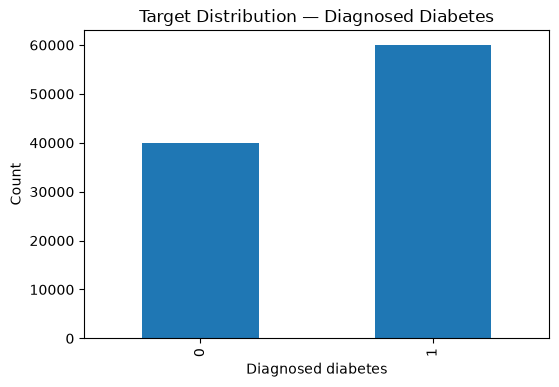

Observation: The two bars show the number of patients in each target class.
Interpretation: The class proportions indicate whether the dataset is balanced.
ML implication: If imbalance is substantial, accuracy alone may be misleading; precision, recall, F1 and ROC-AUC should also be considered.


In [11]:
# 8.1 Target distribution
plt.figure(figsize=(6,4))
clean_df[target_col].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution — Diagnosed Diabetes")
plt.xlabel("Diagnosed diabetes")
plt.ylabel("Count")
plt.show()

print("Observation: The two bars show the number of patients in each target class.")
print("Interpretation: The class proportions indicate whether the dataset is balanced.")
print("ML implication: If imbalance is substantial, accuracy alone may be misleading; precision, recall, F1 and ROC-AUC should also be considered.")


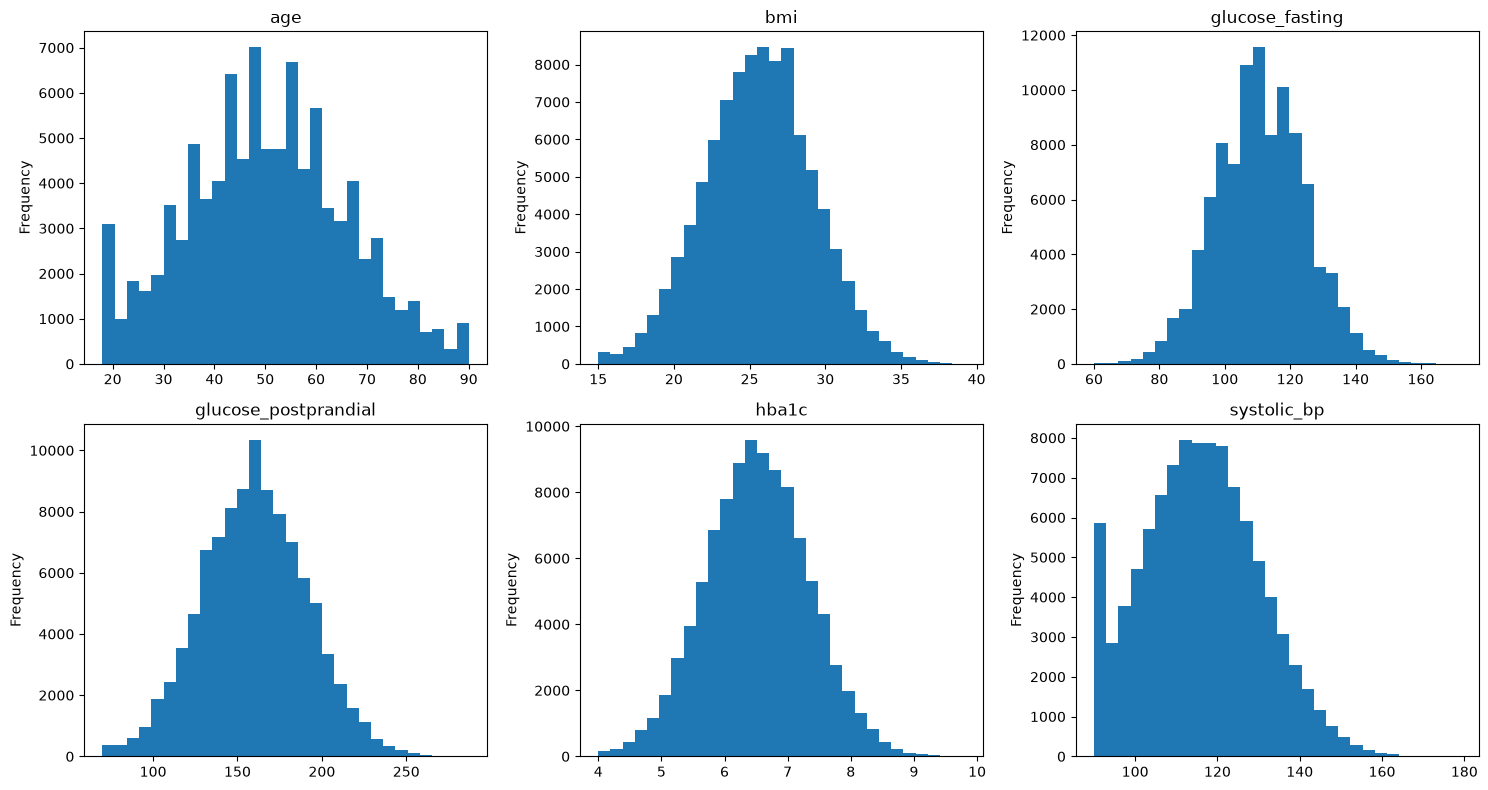

Observation: The histograms show the central tendency and spread of key demographic/clinical variables.
Interpretation: Glucose and HbA1c have clinically meaningful spread, while some variables show skew or extreme values.
ML implication: Scaling is useful for Logistic Regression, SVM and KNN; tree models are less sensitive to feature scale.


In [12]:
# 8.2 Important numerical feature distributions
important_features = ["age", "bmi", "glucose_fasting", "glucose_postprandial", "hba1c", "systolic_bp"]

fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, c in zip(axes.ravel(), important_features):
    clean_df[c].plot(kind="hist", bins=30, ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

print("Observation: The histograms show the central tendency and spread of key demographic/clinical variables.")
print("Interpretation: Glucose and HbA1c have clinically meaningful spread, while some variables show skew or extreme values.")
print("ML implication: Scaling is useful for Logistic Regression, SVM and KNN; tree models are less sensitive to feature scale.")


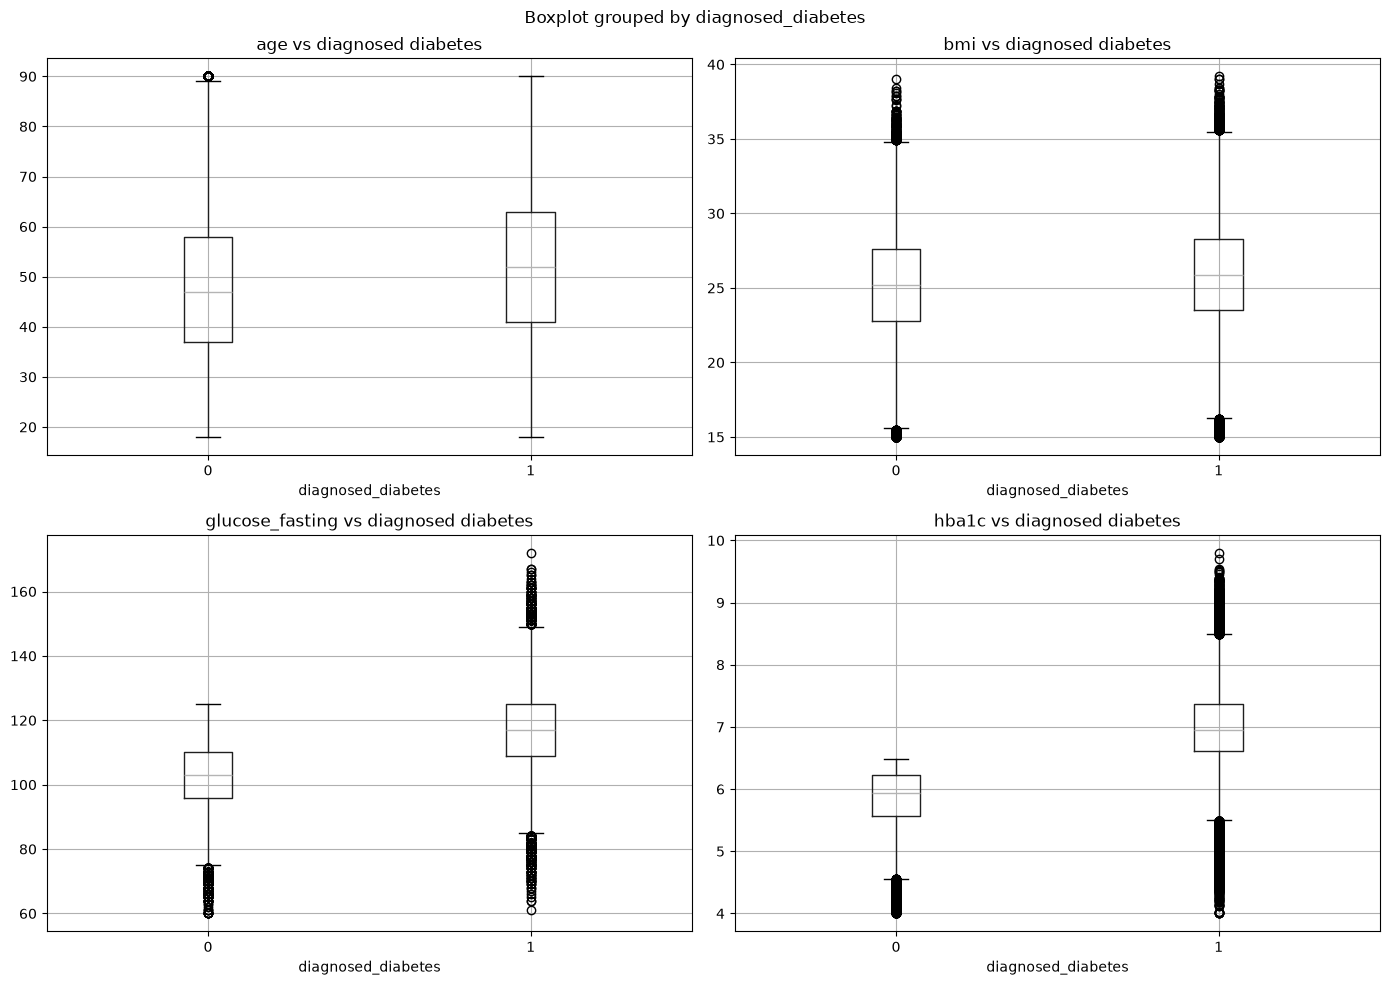

Observation: The boxplots compare the distributions of important features across the two target classes.
Interpretation: Separation between class medians/spreads suggests predictive signal.
ML implication: Features with strong class separation can contribute materially to classification performance.


In [13]:
# 8.3 Feature-target relationships
plot_features = ["age", "bmi", "glucose_fasting", "hba1c"]
fig, axes = plt.subplots(2, 2, figsize=(14,10))
for ax, c in zip(axes.ravel(), plot_features):
    clean_df.boxplot(column=c, by=target_col, ax=ax)
    ax.set_title(f"{c} vs diagnosed diabetes")
plt.tight_layout()
plt.show()

print("Observation: The boxplots compare the distributions of important features across the two target classes.")
print("Interpretation: Separation between class medians/spreads suggests predictive signal.")
print("ML implication: Features with strong class separation can contribute materially to classification performance.")


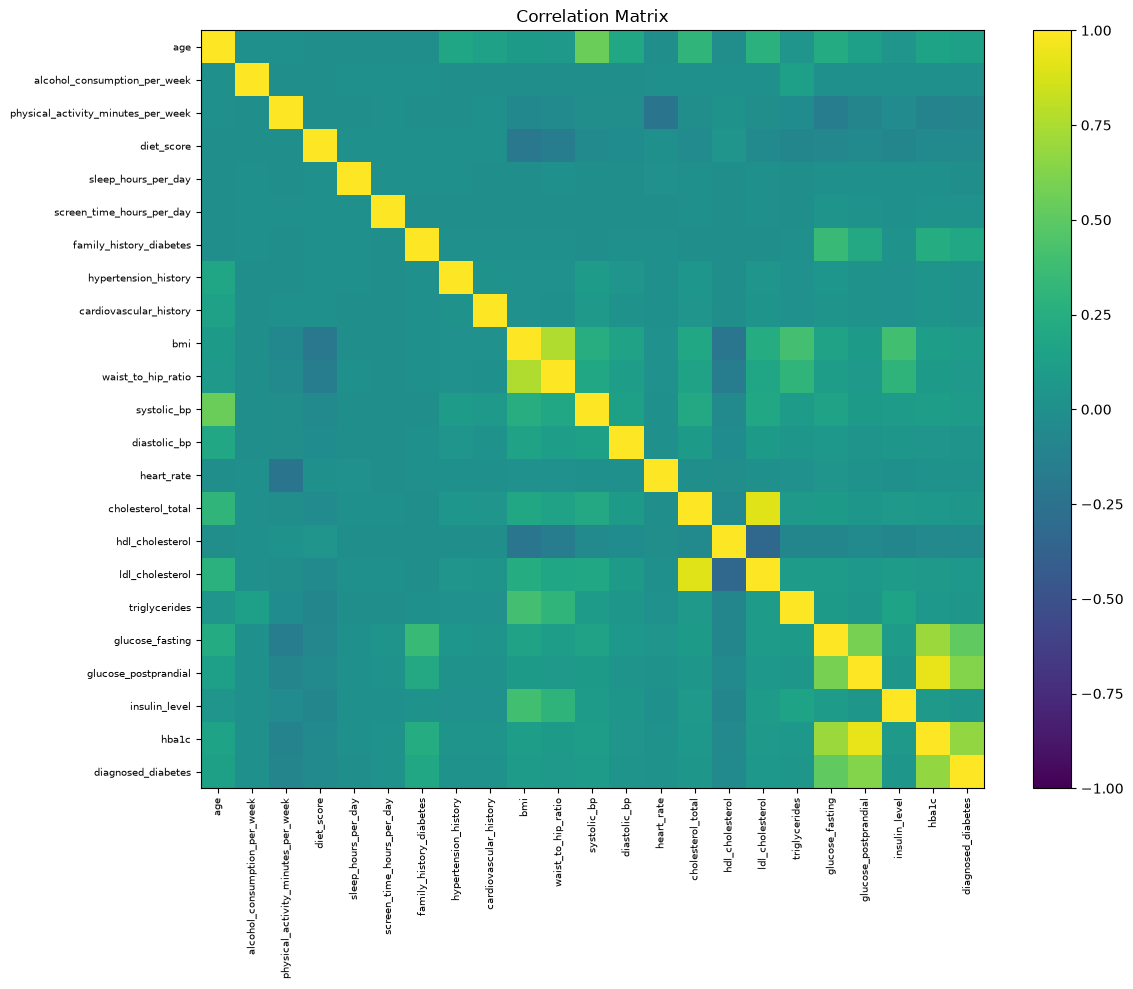

Top absolute correlations with target:


,correlation
hba1c,0.679397
glucose_postprandial,0.629832
glucose_fasting,0.510968
family_history_diabetes,0.197926
age,0.136788
bmi,0.096894
systolic_bp,0.095438
physical_activity_minutes_per_week,-0.092202
waist_to_hip_ratio,0.078918
ldl_cholesterol,0.067475


Observation: The heatmap shows pairwise linear correlations among numerical variables.
Interpretation: High absolute correlation with the target suggests potentially useful linear signal; high feature-feature correlation may indicate redundancy.
ML implication: Correlated predictors can affect linear-model coefficient stability, while tree ensembles can often handle correlated inputs more flexibly.


In [14]:
# 8.4 Correlation analysis
corr_cols = numerical_cols + [target_col]
corr = clean_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12,10))
ax = plt.gca(); im = ax.imshow(corr.to_numpy(), aspect="auto", vmin=-1, vmax=1); ax.set_xticks(range(len(corr.columns))); ax.set_yticks(range(len(corr.index))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7); ax.set_yticklabels(corr.index, fontsize=7); plt.colorbar(im, ax=ax)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

target_corr = corr[target_col].drop(target_col).sort_values(key=np.abs, ascending=False)
print("Top absolute correlations with target:")
display(target_corr.head(10).to_frame("correlation"))

print("Observation: The heatmap shows pairwise linear correlations among numerical variables.")
print("Interpretation: High absolute correlation with the target suggests potentially useful linear signal; high feature-feature correlation may indicate redundancy.")
print("ML implication: Correlated predictors can affect linear-model coefficient stability, while tree ensembles can often handle correlated inputs more flexibly.")


## 9. Baseline Model

A majority-class baseline establishes the minimum reference performance. A useful ML model should improve on this baseline without relying on leakage.

In [15]:
majority_class = y_train.mode()[0]
baseline_pred = np.full(len(y_val), majority_class)

baseline_metrics = {
    "Model": "Majority Class Baseline",
    "Accuracy": accuracy_score(y_val, baseline_pred),
    "Precision": precision_score(y_val, baseline_pred, zero_division=0),
    "Recall": recall_score(y_val, baseline_pred, zero_division=0),
    "F1": f1_score(y_val, baseline_pred, zero_division=0),
}
display(pd.DataFrame([baseline_metrics]))


,Model,Accuracy,Precision,Recall,F1
0,Majority Class Baseline,0.6,0.6,1.0,0.75


## 10. Model Development — Five Required Models

The assignment recommends and requires comparison of five diabetes classifiers:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine
5. KNN

We use `LinearSVC` as the SVM implementation because it is a scalable support-vector classifier for a 100,000-row tabular dataset. It provides a decision score for ROC-AUC without the computational cost of probability calibration.

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(
        n_estimators=250, max_depth=14, min_samples_leaf=5,
        class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_SEED
    ),
    "SVM (LinearSVC)": LinearSVC(C=1.0, class_weight="balanced", max_iter=5000, random_state=RANDOM_SEED),
    "KNN": KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=-1)
}

pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ("preprocessor", ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, numerical_cols),
                ("cat", categorical_transformer, categorical_cols),
            ],
            remainder="drop"
        )),
        ("model", model)
    ])

print("Prepared", len(pipelines), "model pipelines.")


Prepared 5 model pipelines.


In [17]:
# Train and evaluate on validation set
validation_rows = []
trained_pipelines = {}

for name, pipe in pipelines.items():
    print(f"Training {name} ...")
    start = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - start

    pred = pipe.predict(X_val)
    if hasattr(pipe, "predict_proba"):
        score = pipe.predict_proba(X_val)[:, 1]
    else:
        score = pipe.decision_function(X_val)

    validation_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, score),
        "Training Time (s)": elapsed
    })
    trained_pipelines[name] = pipe

validation_results = pd.DataFrame(validation_rows).sort_values("F1", ascending=False).reset_index(drop=True)
display(validation_results)


Training Logistic Regression ...
Training Decision Tree ...
Training Random Forest ...
Training SVM (LinearSVC) ...
Training KNN ...


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Random Forest,0.919800,0.999872,0.866444,0.928389,0.943423,4.586080
1,Decision Tree,0.919533,0.998720,0.867000,0.928210,0.942725,1.096335
2,Logistic Regression,0.889267,0.933184,0.878333,0.904928,0.934720,0.722929
3,SVM (LinearSVC),0.888000,0.931604,0.877778,0.903890,0.934672,0.801483
4,KNN,0.836267,0.868054,0.857444,0.862717,0.908566,0.420662


## 11. Model Evaluation

For classification we report **Accuracy, Precision, Recall, F1-score, confusion matrix and ROC-AUC**, as required by the assignment. fileciteturn0file0L323-L332

For diabetes, **Recall is particularly important** because false negatives represent patients who are predicted as not diabetic despite being in the positive class. However, precision also matters because excessive false positives can create unnecessary follow-up. The final choice therefore considers the full metric profile rather than accuracy alone.

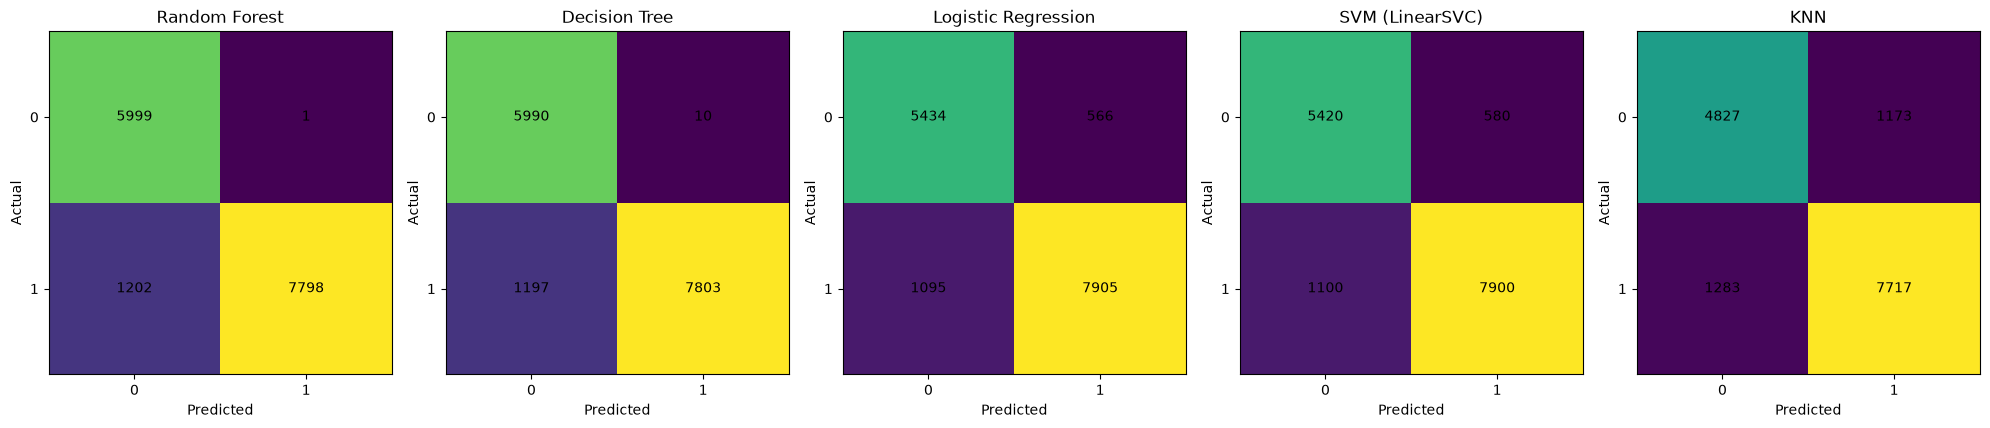

Confusion-matrix interpretation:
TN = correctly predicted non-diabetes; FP = false alarm; FN = missed diabetes case; TP = correctly predicted diabetes.
For this application, FN is especially important because it corresponds to a missed positive case.


In [18]:
# Validation confusion matrices for all five models
fig, axes = plt.subplots(1, 5, figsize=(20,4))
for ax, name in zip(axes, validation_results["Model"]):
    pipe = trained_pipelines[name]
    pred = pipe.predict(X_val)
    cm = confusion_matrix(y_val, pred)
    im = ax.imshow(cm); ax.set_xticks(range(2)); ax.set_yticks(range(2)); ax.set_xticklabels(["0","1"]); ax.set_yticklabels(["0","1"]) 
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha="center", va="center")
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

print("Confusion-matrix interpretation:")
print("TN = correctly predicted non-diabetes; FP = false alarm; FN = missed diabetes case; TP = correctly predicted diabetes.")
print("For this application, FN is especially important because it corresponds to a missed positive case.")


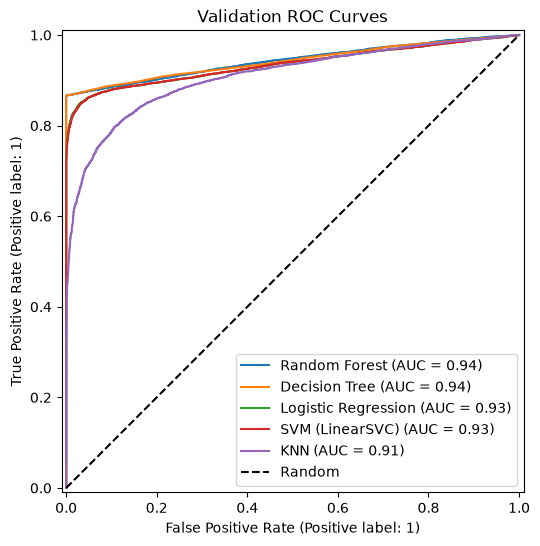

In [19]:
# ROC curves on validation data
plt.figure(figsize=(8,6))
for name in validation_results["Model"]:
    pipe = trained_pipelines[name]
    if hasattr(pipe, "predict_proba"):
        score = pipe.predict_proba(X_val)[:, 1]
    else:
        score = pipe.decision_function(X_val)
    RocCurveDisplay.from_predictions(y_val, score, name=name, ax=plt.gca())
plt.plot([0,1],[0,1],"k--", label="Random")
plt.title("Validation ROC Curves")
plt.legend()
plt.show()


## 12. Model Comparison and Selection

The primary comparison table is the validation-set table above. The final model is selected using validation performance, with emphasis on F1/Recall and consideration of computational cost and robustness.

**Selection rule used in this notebook:** choose the model with the strongest validation F1-score, then use ROC-AUC and Recall as secondary checks. The test set remains untouched during selection.

In [20]:
best_name = validation_results.iloc[0]["Model"]
best_validation_pipe = trained_pipelines[best_name]

print("Selected model based on validation F1:", best_name)
display(validation_results)


Selected model based on validation F1: Random Forest


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Random Forest,0.919800,0.999872,0.866444,0.928389,0.943423,4.586080
1,Decision Tree,0.919533,0.998720,0.867000,0.928210,0.942725,1.096335
2,Logistic Regression,0.889267,0.933184,0.878333,0.904928,0.934720,0.722929
3,SVM (LinearSVC),0.888000,0.931604,0.877778,0.903890,0.934672,0.801483
4,KNN,0.836267,0.868054,0.857444,0.862717,0.908566,0.420662


## 13. Final Test Evaluation

Only after model selection do we evaluate on the held-out test set. We do not fit preprocessing or models using test labels.

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.921,1.0,0.868319,0.929519,0.943038


              precision    recall  f1-score   support

           0     0.8351    1.0000    0.9101      6001
           1     1.0000    0.8683    0.9295      8999

    accuracy                         0.9210     15000
   macro avg     0.9175    0.9342    0.9198     15000
weighted avg     0.9340    0.9210    0.9218     15000



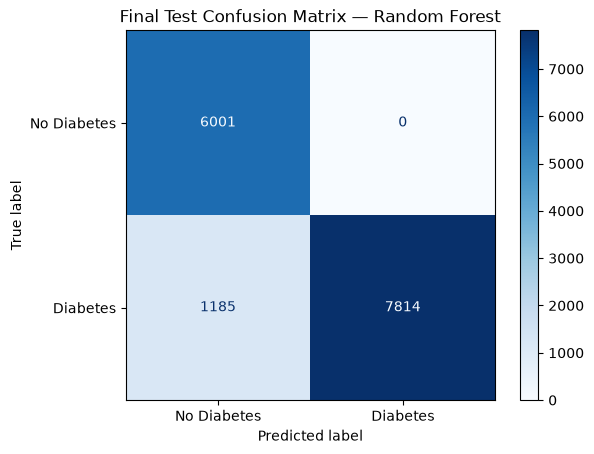

In [21]:
test_pred = best_validation_pipe.predict(X_test)
if hasattr(best_validation_pipe, "predict_proba"):
    test_score = best_validation_pipe.predict_proba(X_test)[:, 1]
else:
    test_score = best_validation_pipe.decision_function(X_test)

test_metrics = {
    "Model": best_name,
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1": f1_score(y_test, test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, test_score)
}
display(pd.DataFrame([test_metrics]))

print(classification_report(y_test, test_pred, digits=4))

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
disp.plot(cmap="Blues")
plt.title(f"Final Test Confusion Matrix — {best_name}")
plt.show()


## 14. Error Analysis

Error analysis focuses on false positives and false negatives. The model should not be judged only by a single score: the types of errors determine practical usefulness.

In [22]:
error_analysis = X_test.copy()
error_analysis["actual"] = y_test.values
error_analysis["predicted"] = test_pred
error_analysis["error_type"] = np.select(
    [
        (error_analysis["actual"] == 0) & (error_analysis["predicted"] == 1),
        (error_analysis["actual"] == 1) & (error_analysis["predicted"] == 0),
        (error_analysis["actual"] == error_analysis["predicted"])
    ],
    ["False Positive", "False Negative", "Correct"],
    default="Other"
)

print("Error counts:")
display(error_analysis["error_type"].value_counts().to_frame("count"))

print("False-negative rate among positive patients:",
      ((error_analysis["error_type"] == "False Negative").sum() / max(1, (error_analysis["actual"] == 1).sum())))


Error counts:


,count
error_type,
Correct,13815
False Negative,1185


False-negative rate among positive patients: 0.13168129792199132


## 15. Model Persistence

The assignment requires saving preprocessing, feature transformation and the trained model so the system can be reused without retraining. A single scikit-learn `Pipeline` is persisted here because it contains both the preprocessing transformer and final estimator. This ensures deployment uses exactly the same preprocessing logic as training. 

In [23]:
MODEL_DIR = "../model"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "diabetes_model_pipeline.joblib")
joblib.dump(best_validation_pipe, MODEL_PATH)

# Save metadata/configuration separately
metadata = {
    "random_seed": RANDOM_SEED,
    "target": target_col,
    "selected_model": best_name,
    "numerical_features": numerical_cols,
    "categorical_features": categorical_cols,
    "dropped_columns": drop_cols,
    "train_shape": list(X_train.shape),
    "validation_shape": list(X_val.shape),
    "test_shape": list(X_test.shape),
    "validation_metrics": validation_results.to_dict(orient="records"),
    "test_metrics": test_metrics,
}
joblib.dump(metadata, os.path.join(MODEL_DIR, "model_metadata.joblib"))

print("Saved:", MODEL_PATH)
print("Saved: ../model/model_metadata.joblib")


Saved: ../model\diabetes_model_pipeline.joblib
Saved: ../model/model_metadata.joblib


## 16. Inference Test

Inference loads the persisted pipeline and predicts a new patient record. No new scaler, encoder or imputer is fitted. This follows the assignment's requirement that deployment must load the preprocessing pipeline learned during training. fileciteturn0file0L1063-L1074

In [24]:
loaded_pipeline = joblib.load(MODEL_PATH)

# One held-out test patient as a reproducible inference example
sample_input = X_test.iloc[[0]].copy()
sample_prediction = loaded_pipeline.predict(sample_input)[0]

if hasattr(loaded_pipeline, "predict_proba"):
    sample_probability = float(loaded_pipeline.predict_proba(sample_input)[0, 1])
else:
    # Convert SVM decision score to a readable value only for demonstration.
    sample_probability = None

display(sample_input)
print("Prediction:", int(sample_prediction))
if sample_probability is not None:
    print("Estimated positive-class probability:", round(sample_probability, 4))
else:
    print("SVM decision score:", float(loaded_pipeline.decision_function(sample_input)[0]))


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c
46462,43.0,Male,Hispanic,Graduate,Middle,Unemployed,Never,2,58,6.2,...,72,88,180.0,55,85,119,108.0,173,16.81,6.71


Prediction: 1
Estimated positive-class probability: 0.9626


## 17. Reproducibility

- Random seed: `42`
- Split: 70% train / 15% validation / 15% test
- Classification split: stratified
- Preprocessing: median imputation + standardization for numerical variables; most-frequent imputation + one-hot encoding for categorical variables
- Models: Logistic Regression, Decision Tree, Random Forest, Linear SVM, KNN
- Persisted artifact: `../model/diabetes_model_pipeline.joblib`
- Metadata: `../model/model_metadata.joblib`

The assignment requests reproducibility information including Python/library versions, random seed, dataset source, preprocessing, feature representation, split, hyperparameters, metrics and saved model/pipeline. 

In [25]:
import sklearn, sys
print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)



Python: 3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]
pandas: 3.0.5
numpy: 2.5.1
scikit-learn: 1.9.0


## 18. Final Discussion

### 1. What does one observation represent?
One row represents one patient record.

### 2. What is the raw representation?
A CSV/table containing numerical, categorical and administrative fields.

### 3. What is the final numerical representation?
A dense feature vector after numeric imputation/scaling and categorical one-hot encoding; all patients form a matrix \(X \in R^{N\times d}\).

### 4. What information was removed?
Identifiers, administrative notes, sparse experimental data, and leakage-prone diabetes-stage/risk-score fields were removed.

### 5. What information was preserved?
Demographic, lifestyle, physiological and laboratory measurements relevant to diabetes classification.

### 6. What could cause data leakage?
Fitting an imputer/scaler/encoder on validation/test data, using the target or post-outcome variables as predictors, or selecting the model using test performance.

### 7. Which model was selected?
The notebook selects the model with the highest validation F1-score, then reports its untouched test performance.

### 8. How is the model persisted?
The complete preprocessing + estimator pipeline is saved with `joblib`.

### 9. Deployment implication
A future `/predict` API should load the same persisted pipeline and send raw feature values through it. It must not retrain or fit preprocessing during inference. The assignment specifies the general API workflow as JSON input → validation → preprocessing → model → JSON output. fileciteturn0file0L1229-L1237

## 19. Assignment Checklist — Diabetes Notebook

- [x] Problem definition
- [x] Dataset loading and source statement
- [x] `shape`, `head`, `info`, `describe`, missing values, duplicates
- [x] Numerical/categorical/text/target identification
- [x] Missing-value analysis
- [x] Duplicate analysis
- [x] Invalid-value analysis
- [x] Outlier analysis
- [x] Class imbalance analysis
- [x] Cleaning with explanations
- [x] Vector representation
- [x] Matrix representation
- [x] Tensor-style representation demonstration
- [x] Encoding and scaling
- [x] 70/15/15 stratified split
- [x] EDA and interpretation
- [x] Five classification models
- [x] Accuracy, Precision, Recall, F1, ROC-AUC
- [x] Confusion matrices and interpretation
- [x] Model comparison
- [x] Final model selection
- [x] Model persistence
- [x] Inference test

### Appendix A project location

This notebook is placed under:

`Assignment_02/diabetes/notebook/`

with data under `data/` and model artifacts under `model/`, matching the required repository structure. 